# Example run

This notebook walks through a complete LAB calculation using the reference
configuration [`config.yaml`](../config.yaml), reproducing the double white dwarf
background of Staelens & Nelemans.

`config.yaml` documents every available setting with its allowed values and defaults.
It is runnable as shipped: a single-metallicity SeBa mock catalogue, a Madau & Dickinson
star formation history, and Planck18 cosmology. Two variants ship alongside it:
`examples/config_SeBa_singleZ.yaml` (the same run, without the explanatory comments)
and `examples/config_vanHaaften_multiZ.yaml`
(a 25-metallicity van Haaften catalogue exercising the multi-metallicity path).

Paths inside a configuration are resolved relative to the configuration file itself,
so this notebook can load `../config.yaml` from the `scripts/` directory and the
catalogue and output paths still resolve correctly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from lisaastrophysicalbackgrounds.gravitational_wave_background import (
    GravitationalWaveBackground,
)

gwb = GravitationalWaveBackground("../config.yaml")

/workspace/rrondeel/my_packages/LISA_Astrophysical_Backgrounds/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The metallicities of this population are None


## Calculate the background

`calculate_GWB` accumulates the three separated contributions, **bulk** (steady
inspiral), **birth** (systems entering the band) and **merger** (systems merging in
band), over the frequency and redshift grids, then applies the cosmological weighting.
With `save_results: True` the results are written to
`results/mock_catalogue_gwb_results.h5` alongside a summary plot.

In [2]:
gwb.calculate_GWB()

frequencies = gwb.f_vals
omega_gw = gwb.omega_f
num_sources = gwb.N_sources_f
var_f = gwb.var_f

GWB:   0%|          | 0/1 [00:00<?, ?batch/s]

GWB: 100%|██████████| 1/1 [00:02<00:00,  2.11s/batch]

GWB: 100%|██████████| 1/1 [00:02<00:00,  2.11s/batch]

Saving results at /workspace/rrondeel/my_packages/LISA_Astrophysical_Backgrounds/results


## The background spectrum

The expectation value of the background energy density, $\Omega_{\rm GW}(f)$.

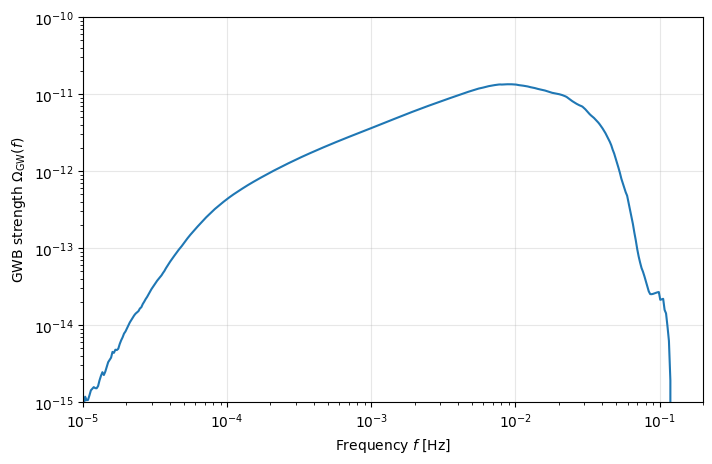

In [3]:
plt.figure(figsize=(8, 5))
plt.loglog(frequencies, omega_gw)
plt.ylabel(r"GWB strength $\Omega_{\rm{GW}}(f)$")
plt.xlabel(r"Frequency $f$ [Hz]")
plt.xlim([1e-5, 2e-1])
plt.ylim([1e-15, 1e-10])
plt.grid(alpha=0.3)
plt.show()

## Variance

LAB propagates an analytic variance estimate alongside the expectation value, so the
Poisson uncertainty of the finite catalogue can be shown directly on the spectrum.

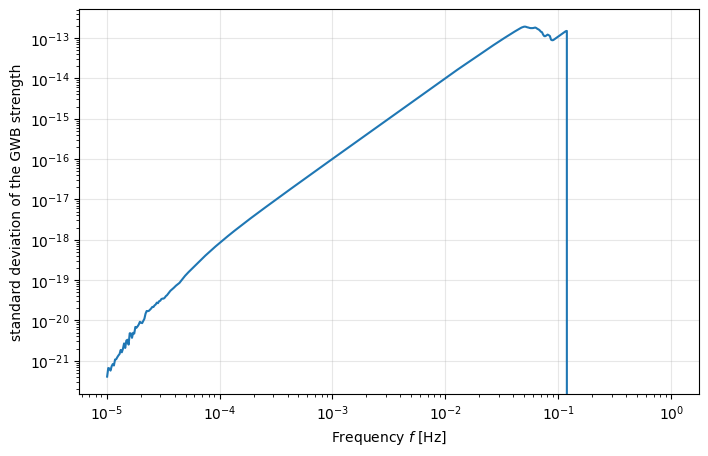

In [4]:
plt.figure(figsize=(8, 5))
plt.loglog(frequencies, var_f ** 0.5)
plt.ylabel(r"standard deviation of the GWB strength")
plt.xlabel(r"Frequency $f$ [Hz]")
plt.grid(alpha=0.3)
plt.show()

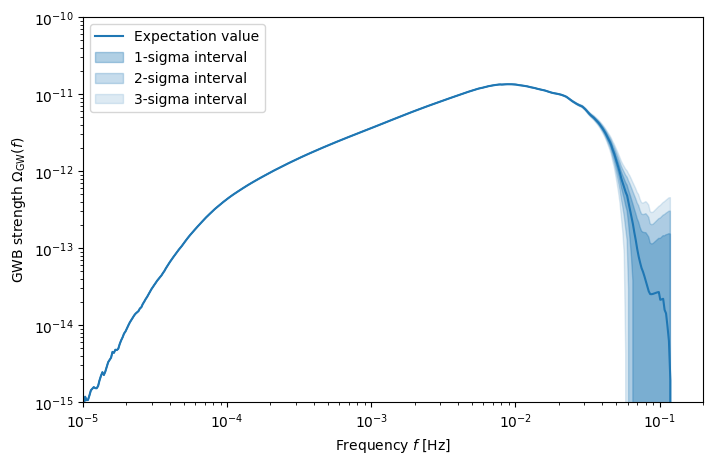

In [5]:
plt.figure(figsize=(8, 5))
plt.loglog(frequencies, omega_gw, label="Expectation value")
for n, alpha in ((1.0, 0.35), (2.0, 0.25), (3.0, 0.15)):
    plt.fill_between(
        frequencies,
        omega_gw - n * var_f ** 0.5,
        omega_gw + n * var_f ** 0.5,
        alpha=alpha,
        label=rf"{n:.0f}-sigma interval",
        color="tab:blue",
    )
plt.ylabel(r"GWB strength $\Omega_{\rm{GW}}(f)$")
plt.xlabel(r"Frequency $f$ [Hz]")
plt.ylim([1e-15, 1e-10])
plt.xlim([1e-5, 2e-1])
plt.legend()
plt.show()

## Where the sources sit in redshift

`N_sources_fz` resolves the source counts over both frequency and redshift, which shows
which shells actually contribute to each part of the band.

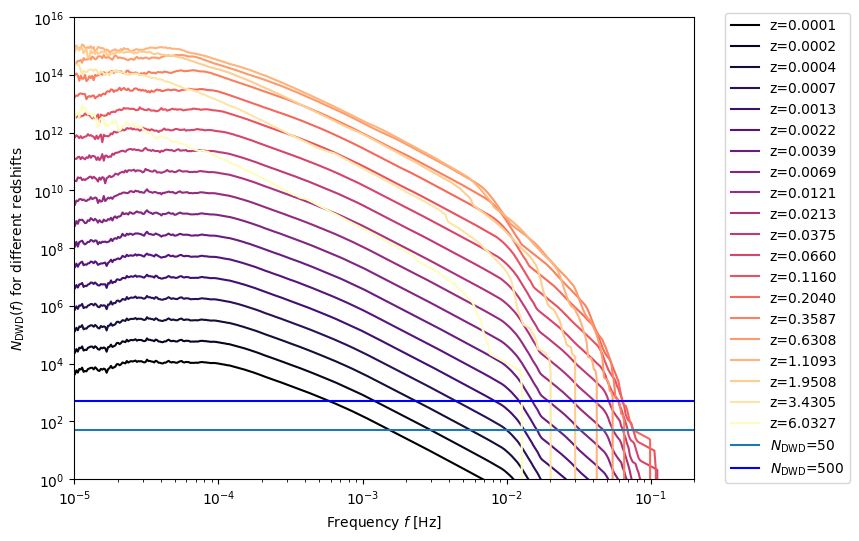

In [6]:
num_syst_fz = gwb.N_sources_fz
num_syst_fz = num_syst_fz.at[num_syst_fz < 0.5].set(0)
z_vals = gwb.cosmology.z_vals

colors = plt.get_cmap("magma")(np.linspace(0, 1, len(z_vals)))

plt.figure(figsize=(8, 6))
for i, z in enumerate(z_vals):
    plt.loglog(frequencies, num_syst_fz[:, i], label=f"z={z:.4f}", color=colors[i])

plt.axhline(5e1, label=r"$N_{\rm{DWD}}$=50")
plt.axhline(5e2, label=r"$N_{\rm{DWD}}$=500", c="b")

plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", borderaxespad=0.0)
plt.xlabel(r"Frequency $f$ [Hz]")
plt.ylabel(r"$N_{\rm{DWD}}(f)$ for different redshifts")
plt.xlim([1e-5, 2e-1])
plt.ylim([1, 1e16])
plt.show()

## Next steps

- Swap `SFH_name` in `config.yaml` for `madau_and_fragos`, `strolger`, `neijssel_2019`,
  or the tabulated `chruslinska_and_nelemans` model and rerun.
- Run `examples/config_vanHaaften_multiZ.yaml` for the multi-metallicity path. The results then additionally
  carry the metallicity-resolved arrays `gwb.omega_fZ` and `gwb.omega_fzZ`.
- Every available setting, with its allowed values and defaults, is documented in
  [`config.yaml`](../config.yaml).